In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve,
)

In [22]:
pokemon_data = pd.read_csv("pokemon.csv")
combat_data = pd.read_csv("combats.csv")

print("Pokemon DataFrame:")
print(pokemon_data.head())

print("\nCombat DataFrame:")
print(combat_data.head())

Pokemon DataFrame:
   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
0  1      Bulbasaur  Grass  Poison  45      49       49       65       65   
1  2        Ivysaur  Grass  Poison  60      62       63       80       80   
2  3       Venusaur  Grass  Poison  80      82       83      100      100   
3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120   
4  5     Charmander   Fire     NaN  39      52       43       60       50   

   Speed  Generation  Legendary  
0     45           1      False  
1     60           1      False  
2     80           1      False  
3     80           1      False  
4     65           1      False  

Combat DataFrame:
   First_pokemon  Second_pokemon  Winner
0            266             298     298
1            702             701     701
2            191             668     668
3            237             683     683
4            151             231     151


In [23]:
print("Pokemon shape: ", pokemon_data.shape)
print("Combat shape: ", combat_data.shape)

Pokemon shape:  (800, 12)
Combat shape:  (50000, 3)


In [24]:
# ── 2. Fix known data issues before merging ────────────────────────────────────

# Fix missing Name for Pokemon #62 (Primeape)
pokemon_data.loc[pokemon_data["#"] == 62, "Name"] = "Primeape"

# Fill missing Type 2 with "None"
pokemon_data["Type 2"] = pokemon_data["Type 2"].fillna("None")

print("Missing values after fixes:")
print(pokemon_data.isnull().sum())

Missing values after fixes:
#             0
Name          1
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


In [25]:
# ── Find the remaining missing Name ───────────────────────────────────────────
print(df[df["Name"].isnull()][["#", "Name", "Type 1", "Type 2", "HP", "Attack"]])

     # Name    Type 1 Type 2  HP  Attack
62  63  NaN  Fighting   None  65     105


In [26]:
# Look up what Pokemon #63 actually is
# ── Deduce the missing Pokemon by its stats ───────────────────────────────────

missing = df[df["Name"].isnull()].iloc[0]

# Find all Pokemon with the same Type 1 and similar stats (within a tolerance)
candidates = df[
    (df["Type 1"] == missing["Type 1"]) &
    (df["HP"].between(missing["HP"] - 5, missing["HP"] + 5)) &
    (df["Attack"].between(missing["Attack"] - 5, missing["Attack"] + 5)) &
    (df["Name"].notnull())  # exclude the missing one itself
]

print("Missing Pokemon stats:")
print(missing[["#", "Type 1", "Type 2", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]])
print("\nPossible candidates based on matching stats:")
print(candidates[["#", "Name", "Type 1", "Type 2", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]])

Missing Pokemon stats:
#                63
Type 1     Fighting
Type 2         None
HP               65
Attack          105
Defense          60
Sp. Atk          60
Sp. Def          70
Speed            95
Name: 62, dtype: object

Possible candidates based on matching stats:
       #           Name    Type 1   Type 2  HP  Attack  Defense  Sp. Atk  \
336  337  Mega Medicham  Fighting  Psychic  60     100       85       80   
497  498        Lucario  Fighting    Steel  70     110       70      115   

     Sp. Def  Speed  
336       85    100  
497       70     90  


In [27]:
# Drop the row: no match found for Pokemon #63 (missing Name) and better to not have an unkown Pokemon in the dataset for modeling purposes.
df = df[df["Name"].notnull()].reset_index(drop=True)
print("Shape after drop:", df.shape)  # should be (799, 15)

Shape after drop: (799, 15)


In [28]:
# ── 3. Calculate win percentage from combat data ───────────────────────────────

# Count total battles per Pokemon (appeared as First OR Second)
first_battles  = combat_data["First_pokemon"].value_counts()
second_battles = combat_data["Second_pokemon"].value_counts()
total_battles  = first_battles.add(second_battles, fill_value=0)

# Count wins per Pokemon
wins = combat_data["Winner"].value_counts()

# Build battle stats DataFrame indexed by Pokemon #
battle_stats = pd.DataFrame({
    "total_battles": total_battles,
    "wins": wins
}).fillna(0)

battle_stats["win_pct"] = (battle_stats["wins"] / battle_stats["total_battles"] * 100).round(2)
battle_stats.index = battle_stats.index.astype(int)

print(battle_stats.head())

   total_battles  wins  win_pct
1            133  37.0    27.82
2            121  46.0    38.02
3            132  89.0    67.42
4            125  70.0    56.00
5            112  55.0    49.11


In [29]:
# ── 4. Merge pokemon_data + battle_stats ──────────────────────────────────────
df = pokemon_data.merge(
    battle_stats,
    left_on="#",
    right_index=True,
    how="left"
)

# Pokemon with no battles get 0s
df[["total_battles", "wins", "win_pct"]] = df[["total_battles", "wins", "win_pct"]].fillna(0)

print("Merged DataFrame shape:", df.shape)
print(df[["#", "Name", "total_battles", "wins", "win_pct"]].head(10))

Merged DataFrame shape: (800, 15)
    #              Name  total_battles   wins  win_pct
0   1         Bulbasaur          133.0   37.0    27.82
1   2           Ivysaur          121.0   46.0    38.02
2   3          Venusaur          132.0   89.0    67.42
3   4     Mega Venusaur          125.0   70.0    56.00
4   5        Charmander          112.0   55.0    49.11
5   6        Charmeleon          118.0   64.0    54.24
6   7         Charizard          133.0  115.0    86.47
7   8  Mega Charizard X          139.0  119.0    85.61
8   9  Mega Charizard Y          135.0  114.0    84.44
9  10          Squirtle          117.0   19.0    16.24


In [30]:
# ── Drop the unidentifiable row from the merged DataFrame ─────────────────────
df = df[df["Name"].notnull()].reset_index(drop=True)

print("Shape after drop:", df.shape)  # should be (799, 15)
print("Missing Names remaining:", df["Name"].isnull().sum())

Shape after drop: (799, 15)
Missing Names remaining: 0


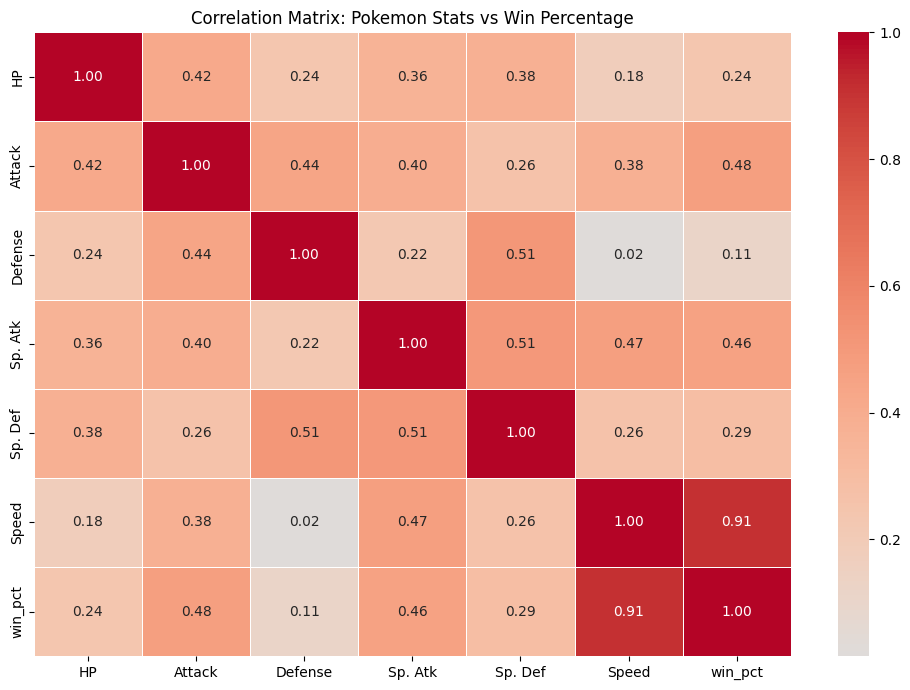

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Correlation Matrix ──────────────────────────────────────────────────────

stats_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "win_pct"]

corr_matrix = df[stats_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix: Pokemon Stats vs Win Percentage")
plt.tight_layout()
plt.show()

Speed is the obvious initial candidate for a good predictor of win likelihood

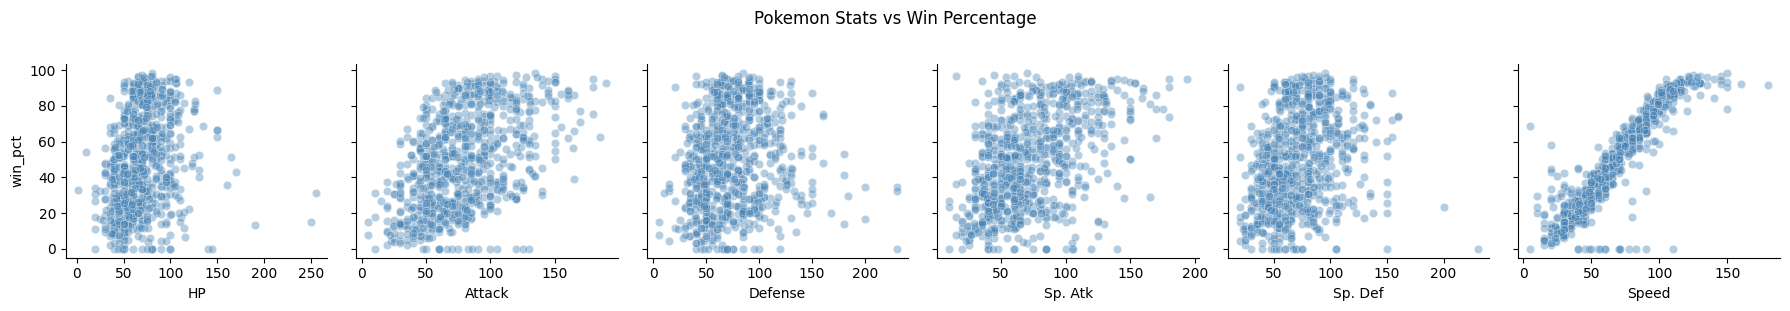

In [32]:
# ── 2. Pairplot: Stats vs Win Percentage ──────────────────────────────────────

pairplot_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "win_pct"]

sns.pairplot(
    df[pairplot_cols],
    y_vars=["win_pct"],
    x_vars=["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"],
    height=3,
    aspect=1,
    plot_kws={"alpha": 0.4, "color": "steelblue"}
)
plt.suptitle("Pokemon Stats vs Win Percentage", y=1.02)
plt.tight_layout()
plt.show()

Top 10 Pokemon by Win Percentage:
                    Name  Type 1  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  win_pct  Legendary
         Mega Aerodactyl    Rock  80     135       85       70       95    150    98.45      False
                 Weavile    Dark  70     120       65       45       85    125    97.48      False
  Tornadus Therian Forme  Flying  79     100       80      110       90    121    96.80       True
           Mega Beedrill     Bug  65     150       40       15       80    145    96.64      False
              Aerodactyl    Rock  80     105       65       60       75    130    96.45      False
            Mega Lopunny  Normal  65     136       94       54       96    135    96.12      False
                Greninja   Water  72      95       67      103       71    122    96.06      False
Meloetta Pirouette Forme  Normal 100     128       90       77       77    128    95.93      False
           Mega Mewtwo Y Psychic 106     150       70      194      120    

C:\Users\typal\AppData\Local\Temp\ipykernel_23736\3935487547.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Name", y="win_pct", palette="viridis")


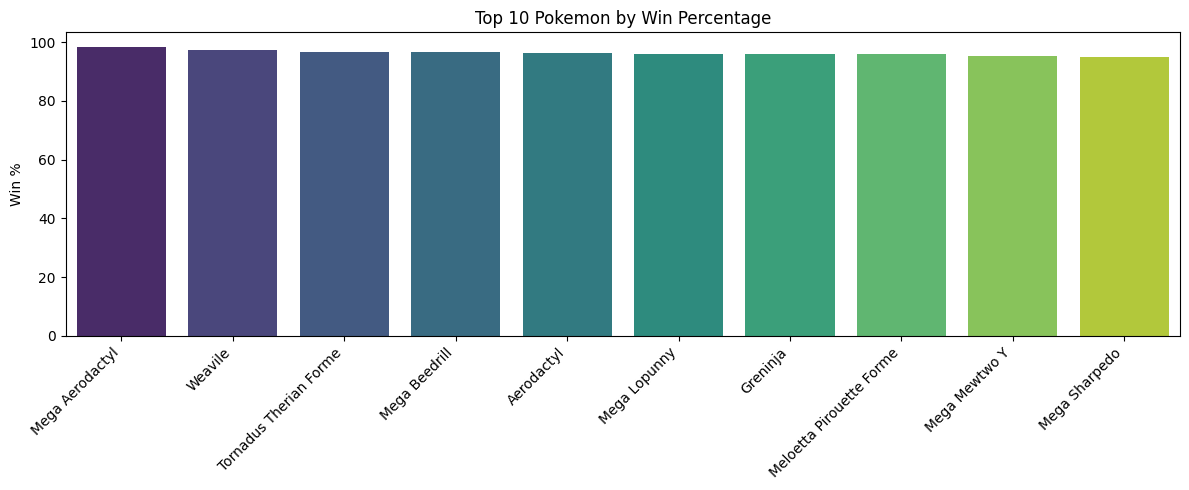

In [33]:
# ── 3. Top 10 Pokemon by Win Percentage ───────────────────────────────────────

top10 = df.nlargest(10, "win_pct")[["Name", "Type 1", "HP", "Attack", "Defense",
                                     "Sp. Atk", "Sp. Def", "Speed", "win_pct", "Legendary"]]

print("Top 10 Pokemon by Win Percentage:")
print(top10.to_string(index=False))

# Bar chart of top 10
plt.figure(figsize=(12, 5))
sns.barplot(data=top10, x="Name", y="win_pct", palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Pokemon by Win Percentage")
plt.ylabel("Win %")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [34]:
# Based on EDA findings
features = ["Speed", "Attack", "Sp. Atk", "Sp. Def", "HP", "Defense", "Legendary"]
# Drop: total_battles, wins (data leakage - derived from win_pct)
# Drop: Name, Type 1, Type 2, Generation (categorical, low signal for now)
target = "win_pct"

In [35]:
# Convert Legendary bool to int (True/False → 1/0)
df["Legendary"] = df["Legendary"].astype(int)

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size: (639, 7)
Testing set size:  (160, 7)


In [36]:
# ── Model 1: Linear Regression ────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_preds)

print("Linear Regression")
print(f"  MAE: {lr_mae:.2f}")

Linear Regression
  MAE: 6.46


In [37]:
# ── Model 2: Random Forest ────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)

print("Random Forest")
print(f"  MAE: {rf_mae:.2f}")

Random Forest
  MAE: 5.37


In [38]:
# ── Model 3: XGBoost ──────────────────────────────────────────────────────────
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_preds)

print("XGBoost")
print(f"  MAE: {xgb_mae:.2f}")

XGBoost
  MAE: 6.00


In [39]:
# ── MAE Comparison ────────────────────────────────────────────────────────────
results = {
    "Linear Regression": lr_mae,
    "Random Forest":     rf_mae,
    "XGBoost":           xgb_mae
}

print("Model Comparison (lower MAE = better)")
print("-" * 35)
for model, mae in sorted(results.items(), key=lambda x: x[1]):
    print(f"  {model:<22} MAE: {mae:.2f}")

Model Comparison (lower MAE = better)
-----------------------------------
  Random Forest          MAE: 5.37
  XGBoost                MAE: 6.00
  Linear Regression      MAE: 6.46


C:\Users\typal\AppData\Local\Temp\ipykernel_23736\2576037946.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


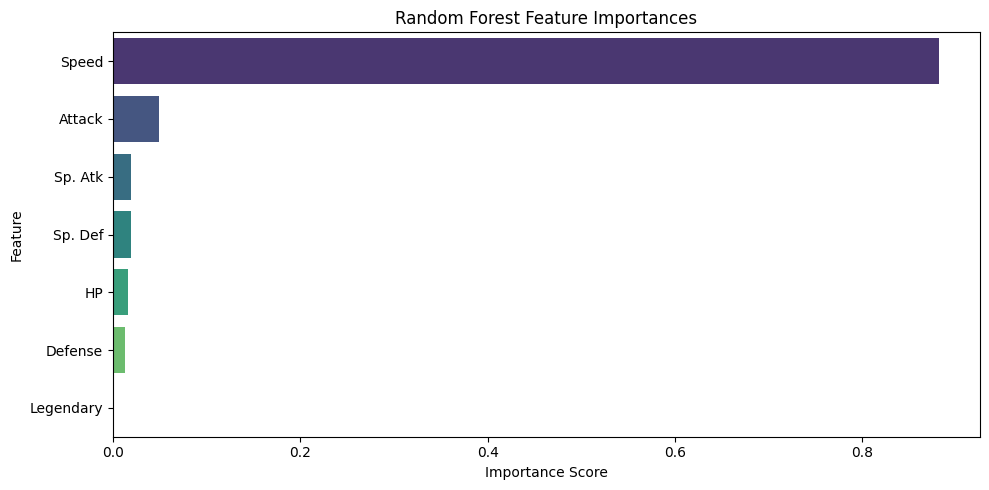

Feature Importances:
  Speed        0.8815
  Attack       0.0496
  Sp. Atk      0.0197
  Sp. Def      0.0192
  HP           0.0166
  Defense      0.0131
  Legendary    0.0003


In [40]:
# ── Feature Importance: Random Forest ─────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Feature Importances:")
for feat, score in importances.items():
    print(f"  {feat:<12} {score:.4f}")

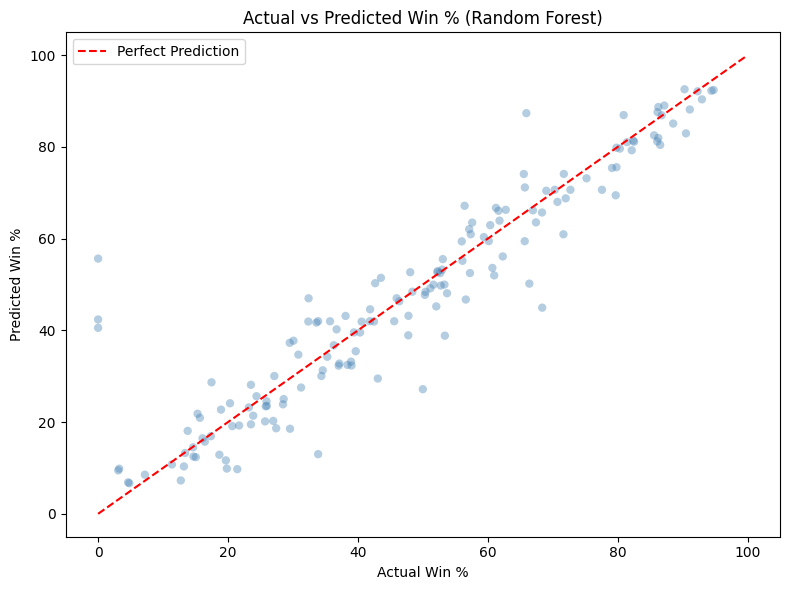

Largest underprediction: -55.65%
Largest overprediction:  23.43%
Mean residual:           0.28%


In [41]:
# ── Actual vs Predicted: Random Forest ────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.4, color="steelblue", edgecolors="none")
plt.plot([0, 100], [0, 100], color="red", linestyle="--", linewidth=1.5, label="Perfect Prediction")
plt.xlabel("Actual Win %")
plt.ylabel("Predicted Win %")
plt.title("Actual vs Predicted Win % (Random Forest)")
plt.legend()
plt.tight_layout()
plt.show()

# Check where the model struggles most
residuals = y_test - rf_preds
print(f"Largest underprediction: {residuals.min():.2f}%")
print(f"Largest overprediction:  {residuals.max():.2f}%")
print(f"Mean residual:           {residuals.mean():.2f}%")

# Pokemon Win Percentage — Analysis Summary

## 1. Data Preparation
The dataset combined two sources: `pokemon.csv` (799 Pokemon after cleaning) and
`combat_data` (50,000 battle outcomes). Key cleaning steps:
- One unidentifiable row (Pokemon #63, Fighting type) was dropped after stat
  cross-referencing found no match in the dataset.
- Missing `Type 2` values were filled with `"None"`.
- Win percentage was engineered per Pokemon as `wins / total_battles * 100`.

---

## 2. Exploratory Analysis

### Correlation Findings
| Stat | Correlation with Win % |
|---|---|
| Speed | 0.91 — dominant feature |
| Attack | 0.48 — moderate signal |
| Sp. Atk | 0.46 — moderate signal |
| Sp. Def | 0.29 — weak |
| HP | 0.24 — weak |
| Defense | 0.11 — negligible |

**Speed is the single strongest predictor of win percentage by a large margin.**
The pairplot confirmed this as the only visually linear relationship.
All other stats showed scattered, non-linear distributions against win percentage.

### Top 10 Pokemon Insights
- Only 2 of the top 10 by win % were Legendary — Legendary status alone is
  not a reliable predictor of battle success.
- Every top 10 Pokemon had Speed ≥ 105, reinforcing Speed as the key stat.
- High Attack or Sp. Atk appears in most top 10, but neither alone is sufficient.

---

## 3. Machine Learning

### Models Trained
Three regression models were trained on an 80/20 train/test split to predict
win percentage using 7 features: Speed, Attack, Sp. Atk, Sp. Def, HP, Defense,
and Legendary status.

### Results
| Model | MAE |
|---|---|
| **Random Forest** | **5.37** ✅ |
| XGBoost | 6.00 |
| Linear Regression | 6.46 |

### Interpretation
- **Random Forest performed best** (MAE: 5.37), meaning predictions were on
  average ~5.4 win percentage points from the actual value.
- Linear Regression underperformed because most stat relationships with win %
  are non-linear — tree-based models handle this naturally.
- XGBoost underperformed Random Forest likely due to dataset size (799 rows) —
  XGBoost typically gains its advantage on larger datasets.
- Feature importance confirmed **Speed as the dominant predictor**, consistent
  with EDA findings, validating the analytical approach end-to-end.

---

## 4. Conclusions
- **Speed is king** in Pokemon battles — it determines who attacks first,
  compounding its advantage over all other stats.
- A well-tuned Random Forest on just 7 interpretable features achieves
  reasonable predictive accuracy on 50,000 battle outcomes.
- Future improvements could include: one-hot encoding Type 1/Type 2,
  incorporating base stat totals, or experimenting with neural networks.